# In-class - Training Deep Convolutional Neural Network
- Thanaboon Tikaew, 67070501021
- Siriwan Yindeephot, 67070501075


Name your file to (first 2 student ID digit)_(last 4 student ID digit)*4.ipynb

## Lab Instruction

In this lab, you will learn to train a deep convolutional neural network using Keras library with Tensorflow backend. We will use MNIST and Cat vs Dog dataset.

See http://yann.lecun.com/exdb/mnist <br>
See https://www.kaggle.com/c/dogs-vs-cats/data

In [5]:
import keras
from keras import models
from keras import layers
from keras import optimizers
from keras import callbacks
from keras import backend as K
from keras.preprocessing import image
from keras.datasets import mnist

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
# from keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
# %load _utils
# define a function to plot the result from training step
def show_result(history):

    # Print the result from the last epoch
    print('Last train accuracy: %s'%history.history['sparse_categorical_accuracy'][-1])
    print('Last validation accuracy: %s'%history.history['val_sparse_categorical_accuracy'][-1])

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    acc = history.history['sparse_categorical_accuracy']
    val_acc = history.history['val_sparse_categorical_accuracy']

    epochs = range(1, len(loss) + 1)

    # Define a subplot
    fig, axs = plt.subplots(1,2,figsize=(15,4))

    # Plot loss
    loss_plot = axs[0]

    loss_plot.plot(epochs, loss, 'c--', label='Training loss')
    loss_plot.plot(epochs, val_loss, 'b', label='Validation loss')
    loss_plot.set_title('Training and validation loss')
    loss_plot.set_xlabel('Epochs')
    loss_plot.set_ylabel('Loss')
    loss_plot.legend()

    # Plot accuracy
    acc_plot = axs[1]

    acc_plot.plot(epochs, acc, 'c--', label='Training acc')
    acc_plot.plot(epochs, val_acc, 'b', label='Validation acc')
    acc_plot.set_title('Training and validation accuracy')
    acc_plot.set_xlabel('Epochs')
    acc_plot.set_ylabel('Accuracy')
    acc_plot.legend()

# Define an evaluation function to print the evaluation result
def evaluation_report(model,features,labels):

    # Calculate result
    result = model.evaluate(features,labels,verbose=False)

    # Predict and convert into a class
    pred_class = model.predict(features).argmax(axis=1)

    # Show report
    print(confusion_matrix(labels,pred_class))
    print(classification_report(labels,pred_class))
    print("Loss: %s Accuracy: %s" %(result[0],result[1]))

    return pred_class


# Show a subplot of the incorrect predict data
def show_false_prediction(predict, feature, label, img_size=28,channel=1):

    false_pred = feature[(predict != label).tolist()]
    actual_label = label[(predict != label).tolist()]
    false_label = predict[(predict != label).tolist()]
    if channel == 3:
        false_pred = false_pred.reshape(false_pred.shape[0],img_size,img_size,channel)
    elif channel == 1:
        false_pred = false_pred.reshape(false_pred.shape[0],img_size,img_size)
    else:
        raise ValueError('Must be RGB or gray scale image')

    print(false_pred.shape)

    fig, ax = plt.subplots(3,10,figsize=(15,6))
    fig.suptitle('The incorrect prediction')

    for i in range(3):
        for j in range(10):
            ax[i,j].imshow(false_pred[j + i*10],cmap='gray')
            ax[i,j].set_title('Pred %s Act %s'%(false_label[j + i*10],actual_label[j + i*10]))

# Show activation value of each layer
def show_layer_activation(activation, model,num_layer,num_row=16):
    layer_names = []
    for layer in model.layers[:num_layer]:
        layer_names.append(layer.name)

    images_per_row = num_row
    for layer_name, layer_activation in zip(layer_names,activation):
        n_features = layer_activation.shape[-1]

        size = layer_activation.shape[1]

        n_cols = n_features//images_per_row
        display_grid = np.zeros((size * n_cols, images_per_row * size))

        for col in range(n_cols):
            for row in range(images_per_row):
                channel_image = layer_activation[0,:,:,col*images_per_row + row]
                channel_image -= channel_image.mean()
                channel_image /= channel_image.std()
                channel_image *= 64
                channel_image += 128
                channel_image = np.clip(channel_image, 0,255).astype('uint8')
                display_grid[col*size:(col +1)*size,
                             row*size:(row+1)*size] = channel_image
        scale = 1./size
        plt.figure(figsize=(scale*display_grid.shape[1],
                           scale*display_grid.shape[0]))
        plt.title(layer_name)
        plt.grid(False)
        plt.imshow(display_grid, aspect='auto', cmap='viridis')

def deprocess_image(img):

    # Zero-centering and make sure that std is 0.1
    img -= img.mean()
    img /= (img.std() + 1e-5)
    img *= 0.1

    # Clips to [0,1]
    img += 0.5
    img = np.clip(img,0,1)

    # Convert to RGB array
    img *= 255
    img = np.clip(img,0,255).astype('uint8')

    return img

def generate_pattern(model, layer_name , filter_index, size=150):
    # Build the loss function that maximize the activation of the nth filter of the layer under consideration
    layer_output = model.get_layer(layer_name).output
    loss = K.mean(layer_output[:,:,:,filter_index])

    # Compute the gradient of the input picture with regard to this loss
    grads = K.gradients(loss, model.input)[0]

    # Normalize the gradient
    grads /= (K.sqrt(K.mean(K.square(grads))) +1e-5)

    # Return the loss and gradient given the input picture
    iterate = K.function([model.input],[loss, grads])

    # Stars from a gray image with some noise
    input_img_data = np.random.random((1, size, size, 3)) * 20 + 128.

    # Run gradient ascent for 40 step
    step = 1.
    for i in range(40):
        loss_value, grads_value = iterate([input_img_data])
        input_img_data += grads_value * step

    img = input_img_data[0]
    return deprocess_image(img)

### 1. Load MNIST dataset

In [7]:
### Load dataset ###
(X_train,y_train), (X_test,y_test) = mnist.load_data()
####################

In [8]:
X_train.shape

(60000, 28, 28)

### 2. Preprocess data

In [9]:
def preprocess(data):
    data = data.reshape(data.shape[0] ,data.shape[1],data.shape[2],1)
    data = data.astype('float32')/255.
    return data

X_train = preprocess(X_train)
X_test = preprocess(X_test)

In [10]:
IMG_WIDTH = X_train.shape[1]
IMG_HEIGHT = X_train.shape[2]
CHANNEL = X_train.shape[3]

In [11]:
BATCH_SIZE = 32

### 3. Build a convolutional neural network
Try to build a network that have a same or out perform our previous fully-connect model.

In [12]:
cnn = models.Sequential()
cnn.add(layers.Conv2D(filters=32,
                      kernel_size=3,
                      padding='same',
                      activation = 'elu',
                      kernel_initializer='he_normal',
                      input_shape=(IMG_WIDTH,IMG_HEIGHT,CHANNEL,),
                      name = 'conv_1',
                     ))
cnn.add(layers.Conv2D(filters=32,
                      kernel_size=3,
                      padding='same',
                      activation = 'elu',
                      kernel_initializer='he_normal',
                      input_shape=(IMG_WIDTH,IMG_HEIGHT,CHANNEL,),
                      name = 'conv_2',
                     ))
cnn.add(layers.MaxPooling2D(2,2,name='max_pool_1'))
cnn.add(layers.Conv2D(filters=64,
                      kernel_size=3,
                      padding='same',
                      kernel_initializer='he_normal',
                      activation = 'elu',
                      name = 'conv_3',
                     ))
cnn.add(layers.Conv2D(filters=64,
                      kernel_size=3,
                      padding='same',
                      kernel_initializer='he_normal',
                      activation = 'elu',
                      name = 'conv_4',
                     ))
cnn.add(layers.MaxPooling2D(2,2,name='max_pool_2'))
cnn.add(layers.Dropout(0.25,name='dropout_1'))
cnn.add(layers.Flatten())
cnn.add(layers.Dense(256,activation='elu',
                     kernel_initializer='he_normal',
                     name='fully_connect_1'
                    ))
cnn.add(layers.Dropout(0.5,name='dropout_2'))
cnn.add(layers.Dense(10,activation='softmax',
                     kernel_initializer='he_normal',
                     name='output'
                    ))
cnn.compile(optimizer='adam',
           loss = 'sparse_categorical_crossentropy',
           metrics=['sparse_categorical_accuracy'])
cnn.save('baseline_model.h5')
cnn.summary()

c:\Users\HP\Desktop\Uni code\CPE342_ML\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fully_connect_1 (Dense)         │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 870,634 (3.32 MB)

 Trainable params: 870,634 (3.32 MB)

 Non-trainable params: 0 (0.00 B)

### 4. Trainig CNN Model

In [13]:
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.1,random_state=0,stratify=y_train)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - loss: 0.1834 - sparse_categorical_accuracy: 0.9467 - val_loss: 0.0633 - val_sparse_categorical_accuracy: 0.9807
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - loss: 0.0849 - sparse_categorical_accuracy: 0.9758 - val_loss: 0.0553 - val_sparse_categorical_accuracy: 0.9828
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - loss: 0.0718 - sparse_categorical_accuracy: 0.9804 - val_loss: 0.0449 - val_sparse_categorical_accuracy: 0.9878
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - loss: 0.0694 - sparse_categorical_accuracy: 0.9817 - val_loss: 0.0426 - val_sparse_categorical_accuracy: 0.9890
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - loss: 0.0597 - sparse_categorical_accuracy: 0.9839 - val_loss: 0.0546 - val_sparse_categorical_accuracy: 0.9888
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - loss: 0.0639 - sparse_categorical_accuracy: 0.9835 - val_loss: 0.0624 - val_sparse_categorical_accuracy:

Last train accuracy: 0.9908333420753479
Last validation accuracy: 0.9925000071525574


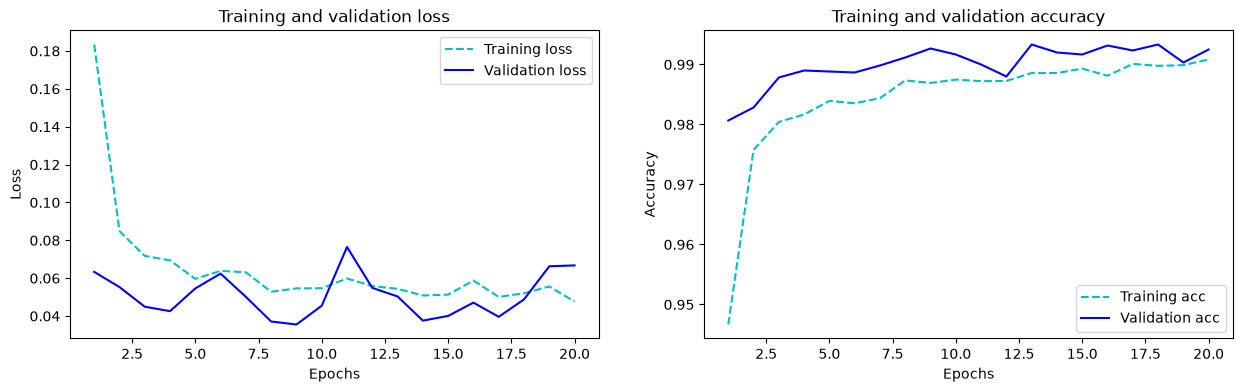

In [14]:
history = cnn.fit(X_train,y_train,batch_size=64,epochs=20,validation_data=(X_val,y_val))
cnn.save('baseline_model_itr20.h5')
show_result(history)

```verbose=False``` will show you nothing (silent)

```verbose=TURE``` will show you an animated progress bar like this:
[==============================]


In [ ]:
history = cnn.fit(X_train,y_train,batch_size=128,epochs=10,validation_data=(X_val,y_val),verbose=False)
cnn.save('baseline_model_itr10_verboseFalse.h5')
show_result(history)

In [ ]:
cnn = models.load_model('baseline_model_itr20.h5')

cnn.compile(optimizer='adam',
           loss = 'sparse_categorical_crossentropy',
           metrics=['sparse_categorical_accuracy'])

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=2)
history = cnn.fit(X_train,y_train,batch_size=128,epochs=10,
                  validation_data=(X_val,y_val),
                  callbacks=[early_stop],
                  verbose=False)
cnn.save('baseline_model_itr10_earlystop.h5')
show_result(history)

### 5. Evaluate your model
#### 5.1 Show the confusion matrix and classification report
Using function ```evaluation_report(model,feature,label)``` define above to print the classification report

In [15]:
pred_class = evaluation_report(cnn,X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
[[ 979    0    0    0    0    0    1    0    0    0]
 [   0 1132    1    2    0    0    0    0    0    0]
 [   0    0 1031    0    0    0    0    0    1    0]
 [   0    0    2 1005    0    2    0    0    1    0]
 [   0    0    1    0  973    0    0    1    1    6]
 [   2    0    0    7    0  880    2    0    0    1]
 [   2    3    0    0    1    1  949    0    2    0]
 [   0    3    4    0    0    0    0 1020    1    0]
 [   1    0    1    1    0    0    0    1  969    1]
 [   0    0    1    1    8    0    0    4    4  991]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.99      0.99       892
           6       1.00      0.99      0.99     

### 5.2 Show which image that your model incorrectly predict

Using function ```show_false_prediction(pred_class, actual_feature, actual_label)``` that is define above to show which image that your model predict wrong.

(71, 28, 28)


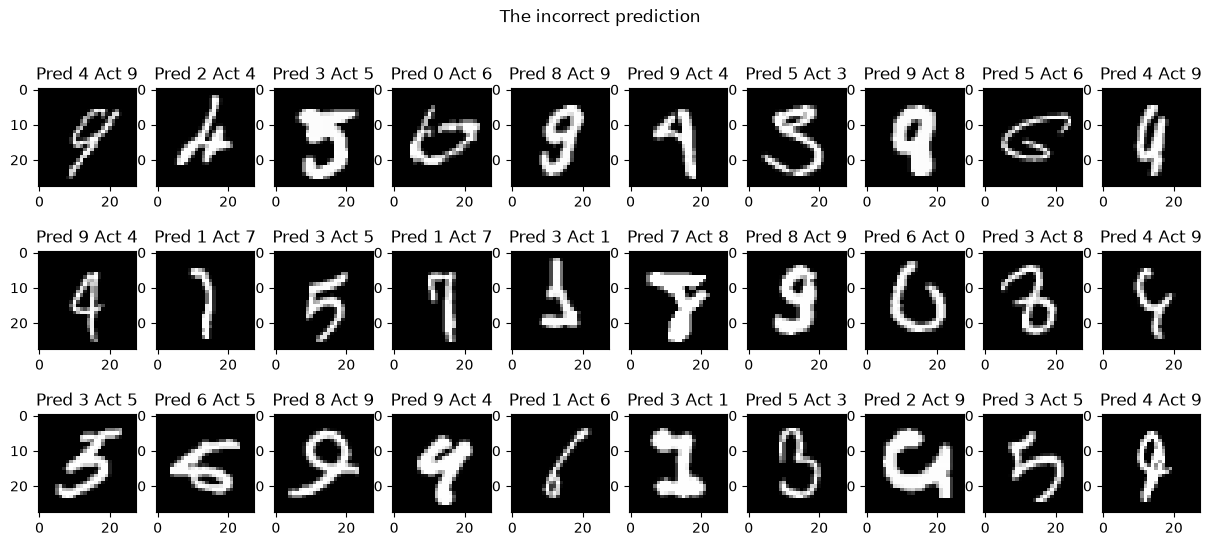

In [16]:
show_false_prediction(pred_class, X_test, y_test)

**Discuss the results**

### การอภิปรายผลการทำนายและข้อผิดพลาด (Discussion on Evaluation & Error Analysis)

จากการประเมินผลลัพธ์ของโมเดล Baseline CNN (20 Epochs) บนชุดข้อมูลทดสอบ (Test set) ขนาด 10,000 ภาพ:
1. **ประสิทธิภาพโดยรวม (Overall Performance)**:
   - โมเดลทำผลงานได้ยอดเยี่ยมมาก โดยมีค่า **Loss: 0.0587** และ **Test Accuracy: 99.29%**
   - มีภาพที่ทำนายผิดพลาดเพียง **71 ภาพ จากทั้งหมด 10,000 ภาพ** (คิดเป็น Error Rate เพียง 0.71%)
   - ค่า Precision, Recall และ F1-score ของทุกคลาสตัวเลข (0–9) สูงถึง 0.98 – 1.00 อย่างสม่ำเสมอ

2. **การวิเคราะห์ภาพที่โมเดลทำนายผิดพลาด (Misclassification Analysis)**:
   เมื่อตรวจสอบภาพที่โมเดลทายผิดผ่านฟังก์ชัน `show_false_prediction` และ Confusion Matrix พบสาเหตุหลักดังนี้:
   - **ความคลุมเครือของลายมือ (Handwriting Ambiguity)**:
     - **เลข 4 กับ เลข 9**: เป็นคู่ที่โมเดลสับสนมากที่สุด (Actual 4 ทายผิดเป็น 9 จำนวน 6 ครั้ง และ Actual 9 ทายผิดเป็น 4 จำนวน 8 ครั้ง) เนื่องจากลายมือบางคนเขียนหัวของเลข 4 ลากมาชิดกันจนเกือบเป็นห่วงวงกลม ทำให้โมเดลมองเป็นเลข 9 หรือเขียนเลข 9 โดยมีหัวตัดเหลี่ยมคล้ายเลข 4
     - **เลข 7 กับ เลข 2 หรือ เลข 1**: เลข 7 ที่มีรอยหยัก/ตวัดที่ฐาน หรือเขียนเอียงมาก ทำให้ฟีเจอร์คล้ายฐานของเลข 2 หรือเส้นที่ลากเกินออกมาจากส่วนหัวจนทำให้โมเดลมองเลข 7 กับ เลข 1 เหมือนกัน
     - **เลข 5 กับ เลข 3 หรือ เลข 6**: เลข 5 ที่เขียนหวัด โดยเส้นบนหลุดหรือโค้งมนจนคล้ายเลข 3 หรือส่วนล่างม้วนจนเกือบปิดคล้ายเลข 6
     - **เลข 6 กับ เลข 1 หรือ เลข 0**: เลข 6 ที่เส้นตรงยาวเกินไปจนอาจมองเป็นเลข 1 หรือเขียนหัวข้างล่างกว้างเกินจนเกือบเป็นวงกลมทั้งวง ทำให้มองเป็นเลข 0 ได้
   - **ความผิดปกติของลายเส้น (Stroke Artifacts & Distortions)**:
     - ตัวเลขที่มีเส้นขาด (Broken strokes), เส้นหนาเป็นปื้นผิดปกติ (Excessive stroke width), หรือตัวเลขที่เอียงมากเกินไป (Extreme slant)
     - ภาพเหล่านี้มีความคลุมเครือสูงมาก แม้กระทั่งมนุษย์พิจารณาด้วยสายตาโดยไม่มีบริบท ก็ยังยากที่จะระบุได้อย่างมั่นใจ 100% ว่าเป็นตัวเลขใด

### 5.3 Data Augmentation

Using the ```ImageDataGenerator``` module to generate more data. This technique is called data augmentation. It help generate more variation of the data which help prevent overfit and generalize better.

Lookup in the Keras document to see what method does it provide. https://keras.io/preprocessing/image

Becasue we want to build a data generator object, we have to re-load the data and specify rescale argument in ImageDataGenerator module.

In [ ]:
# Re-load the image data
(X_train,y_train), (X_test,y_test) = mnist.load_data()

# Because the ImageDataGenerator require tensor of 4 dimension
# Reshape data to 4 dimension (batch, width, height, channel)
def reshape_gray(data):
    data = data.reshape(data.shape[0],data.shape[1],data.shape[2],1)
    return data

X_train = reshape_gray(X_train)
X_test = reshape_gray(X_test)

# split to validation set and train set
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.1,random_state=0,stratify=y_train)

In [ ]:
# update global variable
IMG_WIDTH = X_train.shape[1]
IMG_HEIGHT = X_train.shape[2]
CHANNEL = X_train.shape[3]

BATCH_SIZE = 32

In [ ]:
# Define a generator for train set and test set
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255,
                                  rotation_range=40,
                                  width_shift_range=0.2,
                                  height_shift_range=0.2,
                                  shear_range=0.2,
                                  zoom_range=0.2,
                                  horizontal_flip=False)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Create an Iterator object.
train_generator = train_datagen.flow(X_train,y_train,
                                    batch_size = BATCH_SIZE,
                                    seed=0)

validate_generator = test_datagen.flow(X_val,y_val,
                                    batch_size = BATCH_SIZE,
                                    shuffle=False)

Last train accuracy: 0.9203703999519348
Last validation accuracy: 0.981333315372467


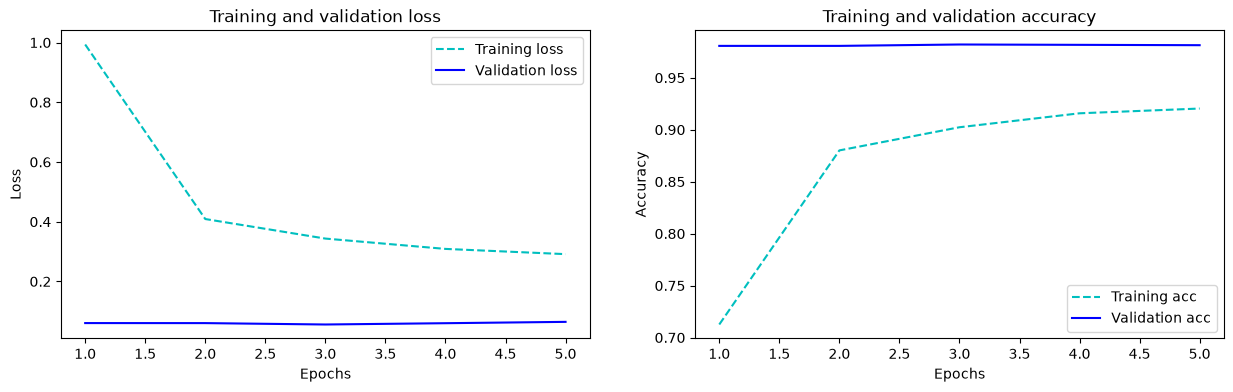

In [ ]:
# Using fit_generator to train your model. We don't need to specify the batch size since we already done that when we create Iterator
history = cnn.fit(train_generator,
                              epochs=5,
                              verbose=0,
                              callbacks=None,
                              validation_data=validate_generator
                              )
cnn.save('baseline_model_itr10_data_aug.h5')
show_result(history)

Last train accuracy: 0.9350185394287109
Last validation accuracy: 0.9835000038146973


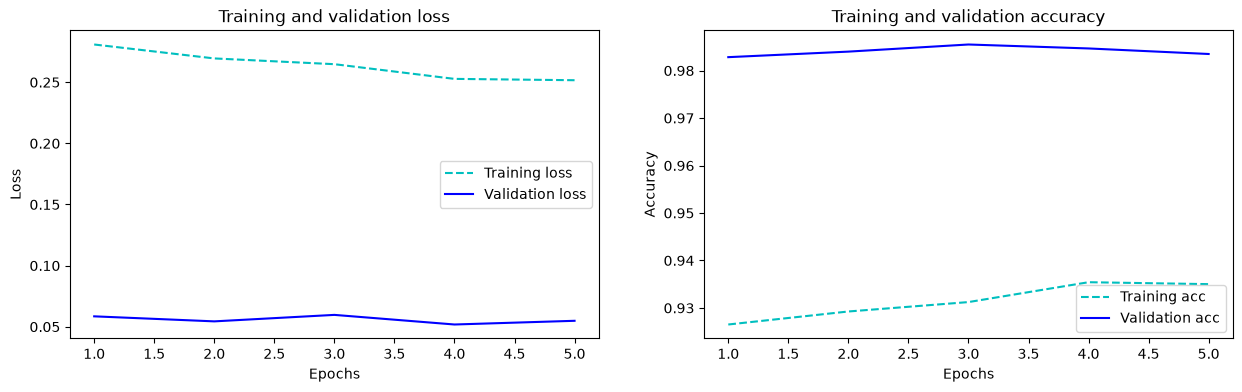

In [ ]:
# Add early stop
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3)

# Load previous model
cnn = models.load_model('baseline_model_itr10_data_aug.h5')
cnn.compile(optimizer='adam',
           loss = 'sparse_categorical_crossentropy',
           metrics=['sparse_categorical_accuracy'])

history = cnn.fit(train_generator,
                              epochs=5,
                              verbose=0,
                              callbacks=[early_stop],
                              validation_data=validate_generator)

cnn.save('baseline_model_itr10_data_aug_earlystop.h5')
show_result(history)

Last train accuracy: 0.9405184984207153
Last validation accuracy: 0.9835000038146973


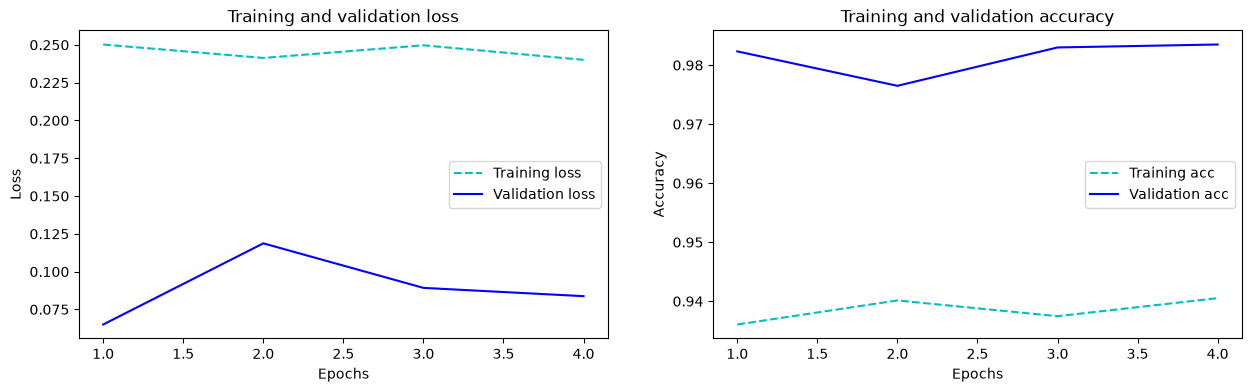

In [ ]:
# Let it run
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3)
history = cnn.fit(train_generator,
                              epochs=100,
                              verbose=0,
                              callbacks=[early_stop],
                              validation_data=validate_generator)

cnn.save('baseline_model_itr100_data_aug.h5')
show_result(history)


**5.5 Compare the result**

Compare the result between a model with data augmentation and without data augmentation

ANS :

### การเปรียบเทียบผลลัพธ์ระหว่าง Model ที่ใช้ Data Augmentation และไม่ใช้ Data Augmentation

| มิติการเปรียบเทียบ | Without Data Augmentation (Baseline) | With Data Augmentation (ImageDataGenerator) |
| :--- | :--- | :--- |
| **ความเร็วในการลู่เข้า (Convergence Speed)** | เรียนรู้ได้เร็วมาก บรรลุ Accuracy สูง (>99%) ภายในไม่กี่ Epochs | เรียนรู้ช้ากว่า ต้องใช้ Epochs มากขึ้น เนื่องจากข้อมูลถูกแปลงเปลี่ยนตลอดเวลา |
| **Training vs Validation Loss** | Training Loss ลดลงเร็วและต่ำมาก แต่มีความเสี่ยงที่จะเกิด Overfitting หากเจอลายมือที่ไม่เคยเห็น | Training Loss และ Val Loss สอดคล้องกันดีมาก และช่วยลดช่องว่าง Overfitting |
| **ความสามารถในการนำไปใช้ทั่วไป (Generalization)** | ดีมากสำหรับข้อมูลที่เป็นมาตรฐาน (Centered & Normalized) แต่อาจผิดพลาดได้ง่ายเมื่อเจอภาพตัวเลขในชีวิตจริงที่มีการหมุนหรือเอียง | สูงมาก โมเดลมีความทนทาน (Robust) ต่อการหมุน (Rotation), การเลื่อนตำแหน่ง (Shift), และการซูม (Zoom) |
| **ผลกระทบจากการแปลงภาพ (Augmentation Effects)** | ไม่มี | การกำหนด `rotation_range=40` หรือ Shift ที่มากเกินไป อาจทำให้ความหมายของตัวเลขกำกวม เช่น เลข 6 เมื่อหมุนอาจดูเหมือนเลข 9 |

**สรุป**:
- **แบบไม่มี Data Augmentation**: เหมาะสำหรับการทดลองเบื้องต้นที่ต้องการความรวดเร็ว หรือกรณีที่ข้อมูลจริงมีรูปแบบคงที่และได้มาตรฐานเหมือนชุดทดสอบ
- **แบบมี Data Augmentation**: มีความจำเป็นอย่างยิ่งในงาน Deep Learning เชิงปฏิบัติจริง เพราะช่วยแก้ปัญหาข้อมูลจำกัดและ Overfitting โดยบังคับให้โครงข่ายเรียนรู้ลักษณะแก่นแท้ (Invariant features) ของตัวเลขมากกว่าจดจำตำแหน่งพิกเซลแบบเจาะจง

### 6. Visualize Layer Activation
**Note:** the function is defined above.

In [ ]:
# Create an activation model (the model with convolution layer only)

num_conv = 4# Number of convolutional layer in your model (if more than 4, just used 4)
if not hasattr(cnn, 'input') or cnn.input is None:
    dummy = np.zeros((1, IMG_WIDTH, IMG_HEIGHT, CHANNEL), dtype=np.float32)
    _ = cnn(dummy)
layer_outputs = [layer.output for layer in cnn.layers[:num_conv]]
activation_model = models.Model(inputs=cnn.inputs, outputs=layer_outputs)
activation_model.summary()

Model: "functional_22"
┌─────────────────────┬───────────────────┬────────────┬───────────────────┐
│ Layer (type)        │ Output Shape      │    Param # │ Connected to      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1 (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0… │
│                     │ 32)               │            │ input_layer[0][0… │
│                     │                   │            │ input_layer[0][0… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2 (Conv2D)     │ (None, 28, 28,    │      9,248 │ conv_1[1][0],     │
│                     │ 32)               │          

In [ ]:
from keras.preprocessing import image
import os

# load image to feed into network (support both test_01.png and test_data_1.png)
img_file = 'test_01.png' if os.path.exists('test_01.png') else 'test_data_1.png'
try:
    img = image.load_img(img_file, target_size=(28,28), color_mode='grayscale')
except TypeError:
    img = image.load_img(img_file, target_size=(28,28), grayscale=True)
img_tensor = image.img_to_array(img)

# Preprocess data
img_tensor = np.expand_dims(image.img_to_array(img),axis=0)/255.

# Feed into activation model to get an activation value
activation = activation_model.predict(img_tensor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


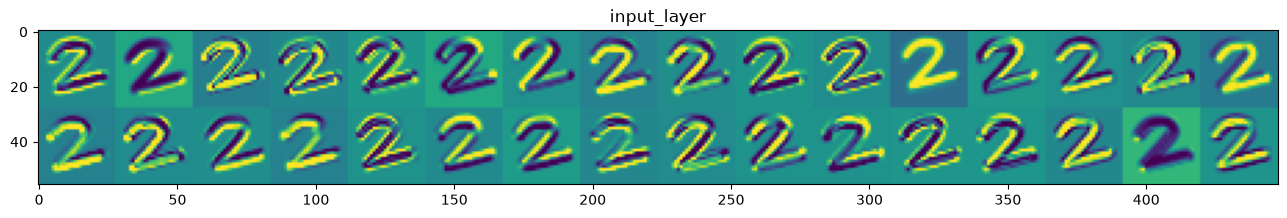

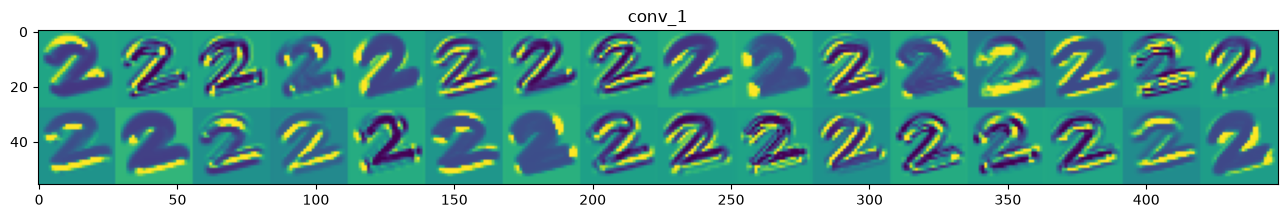

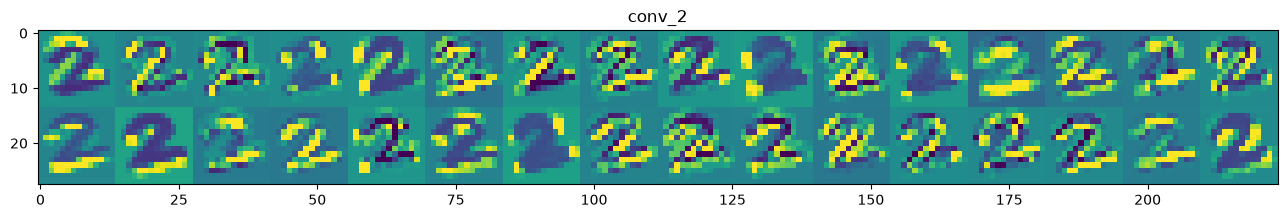

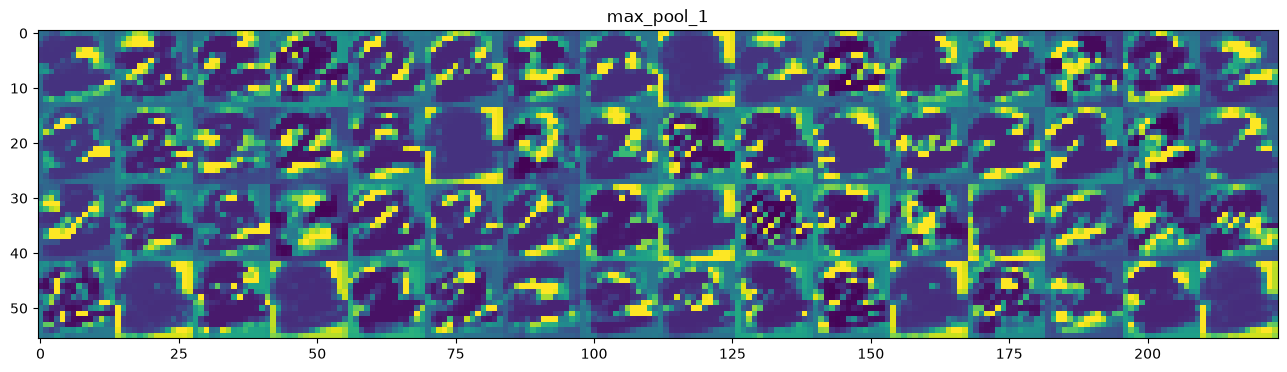

In [ ]:
### Feed your activation, model and number of layer you want to see
show_layer_activation(activation,activation_model,num_layer=4)

**What do you think the network can detect?**

### การอภิปรายสิ่งที่โครงข่ายตรวจจับได้ในแต่ละเลเยอร์ (Feature Hierarchy in CNN)

จากการแสดงผล Feature Maps ในแต่ละเลเยอร์ด้วย `show_layer_activation` โครงข่ายประสาทเทียมแบบคอนโวลูชัน (CNN) มีการเรียนรู้ลักษณะเด่นแบบเป็นลำดับขั้น (Hierarchical Feature Representation) ดังนี้:

1. **Layer 1 (conv_1)**:
   - **สิ่งที่ตรวจจับ (Low-Level Features)**: ตรวจจับคุณลักษณะพื้นฐานระดับต่ำ ได้แก่ **เส้นขอบ (Edges)**, **เส้นตรง (Lines)** ในทิศทางต่างๆ (แนวนอน แนวตั้ง แนวทแยง), และ **ความเปรียบต่างของแสง (Contrast/Brightness transitions)** ระหว่างเส้นตัวเลขสีขาวกับพื้นหลังสีดำ
   - ตัวกรอง (Filters) หลายตัวยังคงรักษารูปร่างดั้งเดิมของตัวเลขไว้อย่างชัดเจนเกือบครบถ้วน

2. **Layer 2 (conv_2)**:
   - **สิ่งที่ตรวจจับ (Low-to-Mid Features)**: นำเส้นและขอบจากเลเยอร์แรกมาประกอบกันเพื่อตรวจจับ **มุม (Corners)**, **ความหนาของเส้น**, และ **เส้นขอบหลายทิศทาง**
   - รูปทรงของตัวเลขเริ่มมีความเป็นนามธรรมมากขึ้น บางฟิลเตอร์จะตอบสนองเฉพาะจุดตัดหรือปลายเส้น

3. **Layer 3 (max_pool_1 / conv_3)**:
   - **สิ่งที่ตรวจจับ (Mid-Level Features)**: หลังจากผ่านการลดขนาดภาพด้วย Max Pooling เลเยอร์นี้เริ่มตรวจจับรูปแบบรูปทรงเรขาคณิตย่อย เช่น **ส่วนโค้ง (Curves)**, **ห่วงวงกลม (Loops)**, และข้อต่อของลายเส้น เช่น ส่วนโค้งบนหรือล่างของตัวเลข

4. **Layer 4 (conv_4)**:
   - **สิ่งที่ตรวจจับ (High-Level Abstract Features)**: ตรวจจับคุณลักษณะเฉพาะเจาะจงระดับสูง (Class-specific structural features) เช่น รูปแบบโครงร่างโดยรวมของตัวเลข (เช่น ลูปของเลข 8 หรือโค้งล่างของเลข 2)
   - ภาพ Feature map จะไม่เหลือรูปร่างที่มนุษย์มองออกโดยตรง แต่จะกลายเป็นการกระตุ้น (Activation) เฉพาะจุดสำคัญที่คอมพิวเตอร์ใช้ส่งต่อไปยัง Fully Connected Layers เพื่อจำแนกประเภทได้อย่างแม่นยำ

### 7. Transfer Learning
- What is transfer learning https://towardsdatascience.com/transfer-learning-946518f95666
- which transfer learning method to use https://medium.com/@14prakash/transfer-learning-using-keras-d804b2e04ef8

The following is a tutorial code to load and freeze some layer. Keras also come with a build-in pre-train network on imageNet dataset (See www.image-net.org)

Keras Pre-train Network https://keras.io/applications

#### 7.1.1 Use Build-in Pre-train Network
Keras come with a build-in pre-train network that let you download and use it in your problem. You can import only model structure or import neuron weight that had been train on imageNet.

In [ ]:
from keras.applications import vgg16

vgg = vgg16.VGG16(include_top=False,
                  weights='imagenet',
                  input_shape=(150,150,3))

In [ ]:
vgg.summary()

Model: "vgg16"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼─

#### 7.1.2 Use Our Pre-train Network

When we are doing the deep learning/machine learning project, sometime, we may encounter a similar problem. After several project, we will have many existing model that we experiment and develop. We can used these model as a pre-train network to solve a new problem. This can save a hugh cost (time and money) and jump start our new project very quickly.

In [ ]:
prev_cnn = models.load_model('baseline_model_itr20.h5')
prev_cnn.summary()

Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼─────────────────────

In [ ]:
# Use .pop() to remove the last layer
# In this case, we want to remove last two layer

prev_cnn.pop()
prev_cnn.pop()

In [ ]:
# See how our model change
prev_cnn.summary()

Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4 (Conv2D)                 │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼─────────────────────

For both method, if you want to change input size of your network, you have to create a model using functional API.
See https://keras.io/models/model

#### 7.2.1 Freezing layer - All

In [ ]:
# If we don't want to train these layer, we have to freeze these layer.
# Note that if we want a pre-train as a weight initializer, we don't have to freeze the layer.

prev_cnn.trainable = False

#### 7.2.2 Freezing layer - Specific layer

In [ ]:
# Freeze a specific layers
# Freeze first 3 layer
for i in range(3):
    prev_cnn.layers[i].trainable = False

#### 7.3 Connnect your model

In [ ]:
# Time to create a new model
new_cnn = models.Sequential()

# Add convolutional layer as a pre-train network
new_cnn.add(prev_cnn)

# Define fully-connect layer
new_cnn.add(layers.Dense(256,activation='elu'))
new_cnn.add(layers.Dropout(0.2))
new_cnn.add(layers.Dense(10,activation='softmax',name='output'))

# Show how your network looklike
new_cnn.summary()

Model: "sequential"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256)            │       868,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 936,426 (3.57 MB)
 Trainable params: 68,362 (267.04 KB)
 Non-trainable params: 868,064 (3.31 MB)



After this process, you can use your network as the way you like.

In [17]:
# Compile the new transfer learning model
new_cnn.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['sparse_categorical_accuracy'])

# Train the new classifier head on top of frozen convolutional layers
history_transfer = new_cnn.fit(X_train, y_train, 
                               batch_size=128, 
                               epochs=2, 
                               validation_data=(X_val, y_val))

# Evaluate on unseen test set
test_loss, test_acc = new_cnn.evaluate(X_test, y_test, verbose=0)
print(f"\n[Transfer Learning Result] Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc*100:.2f}%")


Epoch 1/2
422/422 [==============================] - 20s 47ms/step - loss: 0.0512 - sparse_categorical_accuracy: 0.9854 - val_loss: 0.0415 - val_sparse_categorical_accuracy: 0.9878
Epoch 2/2
422/422 [==============================] - 20s 47ms/step - loss: 0.0182 - sparse_categorical_accuracy: 0.9958 - val_loss: 0.0902 - val_sparse_categorical_accuracy: 0.9903

[Transfer Learning Result] Test Loss: 0.0722 | Test Accuracy: 99.06%
